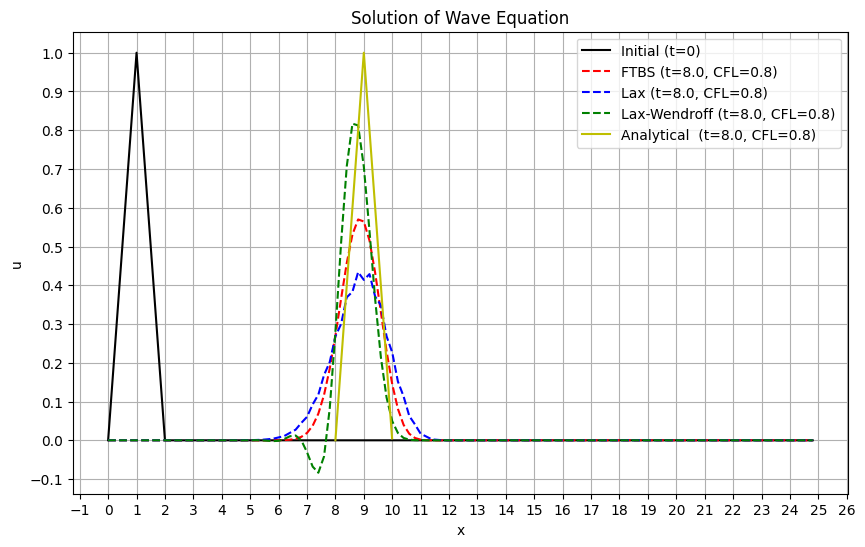

In [1]:
"""solution of the 1D wave equation with three different numerical schemes ,FTBS,Lax, Lax-Wendroff 
   in the context of the class 'Computational Fluid Dynamics-Aerodynamics"""

import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.ticker as tick
  
L=1 # characteristic length
c=1 # speed of wave propagation 

#-----Discretization of space and time domain------
S_total=25*L  # space domain 
t_end=8.0  # time domain 
dx=L/5 #  definition of space discretization step 
x=np.arange(0,S_total,dx) # space discretization 
CFL=0.8 # definition  of CFL number for stability  
dt=CFL*dx # derivation of time step through CFL
N=len(x) #total amount of steps 
time_step=int(t_end/dt)  # time domain discretization

#-------define the initiial condtions-----
def triangular(x):
    """Function that creates a triangular wave as given in the problem.
       It serves as the initial condition of the problem at t=0."""
    u_in=np.zeros_like(x)   # create an array for velocity values , for every spatial step.

    #create the triangular initial wave  
    u_in[(x>=0) & (x<=L)]=x[(x>=0) & (x<=L)]   # ascending part of the wave
    u_in[(x>L) & (x<=2*L)]=2*L-x[(x>L) & (x<=2*L)]  #descending part of the wave 
    return u_in


#call the function 
u_first=triangular(x)

#---------FTBS Scheme---------
#input is the velocity array for every step at some point in time t and the CFL number. 
def FTBS(u_in,CFL):
    """ Function created for the FTBS scheme. Inputs are the velocity array for every step at some point in time t
      and the CFL number. An array is created with the same size and data as the input array. New velocities are
       calculated and dumped to that array. Boundary conditions are also stated """
    
    u_next_step=u_in.copy()  #new array that will store the updated velocities
    u_next_step[1:]=u_in[1 :] -CFL*(u_in[1 :]-u_in[:-1])   #ftbs scheme, [1 :] from second spatial point to last , u[: -1] from first spatial point until the one before the last
    u_next_step[0]=0
    u_next_step[0]=u_next_step[-1] # boundary conditions with velocity of spatial points at the corner.
    return u_next_step # get the array with all the new velocities calculated at the j+1 time step 

#---------LAX Scheme-----------------
def Lax(u_in,CFL):
    """ function for the lax scheme created in the same manner as the FTBS  scheme"""
    u_next_step_lax=u_in.copy()
    u_next_step_lax[1:-1]=(u_in[2:] + u_in[:-2])/2 -(CFL/2)*(u_in[2:] - u_in[:-2])  # Central differences are used so the first and last spatial points are excluded.
    u_next_step_lax[-1]=0 # set boundary conditions 
    u_next_step_lax[0]=u_next_step_lax[-1]
    return u_next_step_lax

#----------LAX-WENDROFF Scheme------------
def Lax_Wendroff(u_in,CFL):
    """Lax-wendroff scheme function , method is similar to the other two"""
    u_next_step_LW=u_in.copy()
    u_next_step_LW[1:-1]=u_in[1:-1]-(u_in[2:]-u_in[:-2])*(CFL/2)+(u_in[2:]-2*u_in[1:-1]+u_in[:-2])*(CFL**2)*(1/2)
    u_next_step_LW[-1]=0 #set boundary conditions 
    u_next_step_LW[0]=u_next_step_LW[-1]
    return u_next_step_LW
    
#initialize matrices before calling the scheme functions
u = u_first.copy()  
u_lax=u_first.copy()
u_lax_wendroff=u_first.copy()


for i in range(time_step):  # run each scheme to calculate the velocity at every time step.
   u=FTBS(u,CFL)
   u_lax=Lax(u_lax,CFL)
   u_lax_wendroff=Lax_Wendroff(u_lax_wendroff,CFL)
 
   
   
##analytical 
x1=np.arange(c*t_end,c*(t_end+2),0.005)
u_tria=np.zeros(len(x1))
u_tria[(x1>=(c*t_end)) & (x1<=c*(t_end+1))]=(x1-c*t_end)[(x1>=(c*t_end)) & (x1<=c*(t_end+1))]   # ascending part of the wave
u_tria[(x1>c*(t_end+1)) & (x1<=c*(t_end+2))]=(c*t_end+2)-x1[(x1>c*(t_end+1)) & (x1<=c*(t_end+2))]  #descending part of the wave 

# Plot final solution for each scheme in a combined graph 
plt.figure(figsize=(10, 6))
plt.plot(x, u_first, 'k-', label='Initial (t=0)')
plt.plot(x, u, 'r--', label=f'FTBS (t={t_end}, CFL={CFL})')
plt.plot(x, u_lax, 'b--', label=f'Lax (t={t_end}, CFL={CFL})')
plt.plot(x, u_lax_wendroff, 'g--', label=f'Lax-Wendroff (t={t_end}, CFL={CFL})')
plt.plot(x1, u_tria, 'y', label=f'Analytical  (t={t_end}, CFL={CFL})')
plt.gca().xaxis.set_major_locator(tick.MultipleLocator(1))  
plt.gca().yaxis.set_major_locator(tick.MultipleLocator(0.1))
plt.xlabel('x')
plt.ylabel('u')
plt.title('Solution of Wave Equation')
plt.legend()
plt.grid(True)
plt.show()


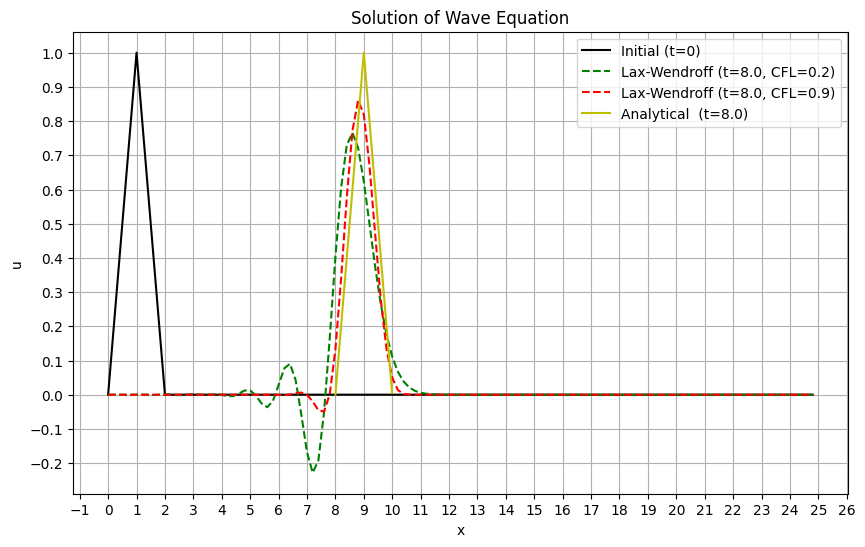

In [2]:
u_lax_wendroff_1=u_first.copy()
u_lax_wendroff_2=u_first.copy()
dt_1=0.2*dx
time_step_1=int(t_end/dt_1)

dt_2=0.9*dx
time_step_2=int(t_end/dt_2) 
for j in range(time_step_1):  # run each scheme to calculate the velocity at every time step.
   u_lax_wendroff_1=Lax_Wendroff(u_lax_wendroff_1,0.2)
  
for k in range(time_step_2):
   u_lax_wendroff_2=Lax_Wendroff(u_lax_wendroff_2,0.9)   
   
   


plt.figure(figsize=(10, 6))
plt.plot(x, u_first, 'k-', label='Initial (t=0)')
plt.plot(x, u_lax_wendroff_1, 'g--', label=f'Lax-Wendroff (t={t_end}, CFL={0.2})')
plt.plot(x, u_lax_wendroff_2, 'r--', label=f'Lax-Wendroff (t={t_end}, CFL={0.9})')
plt.plot(x1, u_tria, 'y', label=f'Analytical  (t={t_end})')
plt.gca().xaxis.set_major_locator(tick.MultipleLocator(1))  
plt.gca().yaxis.set_major_locator(tick.MultipleLocator(0.1))
plt.xlabel('x')
plt.ylabel('u')
plt.title('Solution of Wave Equation')
plt.legend()
plt.grid(True)
plt.show()

Stability term is: 0.15000000000000002
Stability term is: 0.15407441223464963
Stability term is: 0.1567861585727152
Stability term is: 0.15890578995037213
Stability term is: 0.16073727350656
Stability term is: 0.16240593909077178
Stability term is: 0.1635716783407225
Stability term is: 0.1645774316781105
Stability term is: 0.1655869267341643
Stability term is: 0.16659864403034613
Stability term is: 0.167612209980051
Stability term is: 0.16862774193738664
Stability term is: 0.169645563733941
Stability term is: 0.1706660752462618
Stability term is: 0.17168969115543617
Stability term is: 0.17271681250730775
Stability term is: 0.17374781436017178
Stability term is: 0.17470707212396241
Stability term is: 0.17542526200485167
Stability term is: 0.1761630496226104
Stability term is: 0.17691892635596584
Stability term is: 0.17769163102180807
Stability term is: 0.17848009996264858
Stability term is: 0.17928342897264044
Stability term is: 0.18010084387860856
Stability term is: 0.18093167754085043

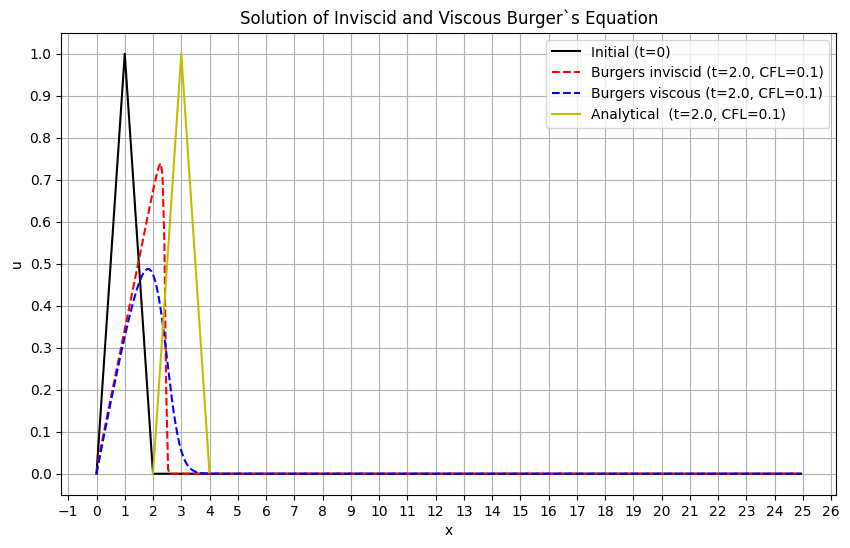

In [3]:
""" Solution of non linear inviscid Burger's equation and the non linear convection Burger's Equation  """

import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.ticker as tick
  
L=1 # characteristic length
c=1 # speed of wave propagation 

#-----Discretization of space and time domain------
S_total=25*L  # space domain 
t_end=2.0 # time domain 
dx=L/15 #  definition of space discretization step 
x=np.arange(0,S_total,dx) # space discretization 
CFL=0.1 # definition  of CFL number for stability  

N=len(x) #total amount of steps 


#-------define the initiial condtions-----
def triangular(x):
    """Function that creates a triangular wave as given in the problem.
       It serves as the initial condition of the problem at t=0."""
    u_in=np.zeros_like(x)   # create an array for velocity values , for every spatial step.

    #create the triangular initial wave  
    u_in[(x>=0) & (x<=L)]=x[(x>=0) & (x<=L)]   # ascending part of the wave
    u_in[(x>L) & (x<=2*L)]=2*L-x[(x>L) & (x<=2*L)]  #descending part of the wave 
    return u_in


#call the function 
u_first=triangular(x)


def inviscid_Burgers(u_in,CFL,dx):
    """Function that solves the inviscid Burger's equation. Time discretization is set
     through CFL and max velocity (calculated in the previous time step). Max velocity must be 
     positive so an if check is implemented. The scheme and the boundary conditions follow.
     The function returns the velocity at every space point in the next time step and it also
     returns the calculated dt.   """
    
    u_next_step_inviscid=u_in.copy() #initiate a velocity array of the same size and data
    u_max=np.max(u_in) # calculate max velocity
    #print('umax is',u_max)
    #check if velocity is positive, if not then set velocity as a very small value
    if u_max>0:
      dt=CFL*dx/u_max
    else:
        dt = CFL * dx / 1e-10
    #print('timestep',time_step)
    u_next_step_inviscid[1:-1] = u_in[1:-1] - 0.5 * (dt/dx) * ( u_in[1:-1]**2 - u_in[:-2]**2) # numerical scheme 
    u_next_step_inviscid[0]=u_next_step_inviscid[-1] # boundary conditions
    return u_next_step_inviscid,dt

def viscous_burgers(u_in,CFL,dx,v):
    """Function that solves the viscous Burger's equation. Time discretization is set
     through CFL and max velocity (calculated in the previous time step). Max velocity must be 
     positive so an if check is implemented. The scheme and the boundary conditions follow.
     The function returns the velocity at every space point in the next time step and it also
     returns the calculated dt.Time discretization is different than inviscid Burger's since 
     max velocity is different.   """

    u_next_step_viscous=u_in.copy() 
    u_max_v=np.max(u_in)
    if u_max_v>0:
      dt_v=CFL*dx/u_max_v #dt calcution 
    else:
        dt_v = 0.00001  #make sure that velocity is never zero3
    u_next_step_viscous[1:-1] = u_in[1:-1] -0.5*(dt_v/dx) * ( u_in[1:-1]**2 - u_in[:-2]**2)+v*(dt_v/dx**2)*(u_in[2:]-2*u_in[1:-1]+u_in[:-2]) #numerical scheme
    u_next_step_viscous[0] = u_next_step_viscous[-1] #boundary conditions 
   
    return u_next_step_viscous,dt_v


u_inviscid=u_first.copy() #initialize the inout velocity matrix as the initial triangular wave 
t=0 #initialize time 

while t<=t_end:
   """ run a while loop that will end only when the defined time is reached. Funtion for the equaion 
   will be called and velocity matrix is going to be updated for every run. While is used because dt 
   is changing at each run."""
   u_inviscid, dt = inviscid_Burgers(u_inviscid, CFL,dx)  # Update u_inviscid and dt
   t += dt # move to the next time step


u_viscous=u_first.copy() #initializaton of velocity matrix 
t_v=0    #initialization of time 
while t_v<=t_end:
   """ Similar procedure as the inviscid case. Different while sections are used since
   dt is different for the two equations. A check is implemented to control if the diffusion stability term
   is exceeded. Since the dt value changes for each run, the stability term also changes. Thus it must be checked
   in every loop."""

   u_viscous,dt_v=viscous_burgers(u_viscous,CFL,dx,0.1)
   t_v += dt_v
   
   if 0.1*dt_v/dx**2>0.46:
      print('--------------error------------')
   else:
      print('Stability term is:',0.1*dt_v/dx**2)


##analytical 
x1=np.arange(c*t_end,c*(t_end+2),0.005)
u_tria=np.zeros(len(x1))
u_tria[(x1>=(c*t_end)) & (x1<=c*(t_end+1))]=(x1-c*t_end)[(x1>=(c*t_end)) & (x1<=c*(t_end+1))]   # ascending part of the wave
u_tria[(x1>c*(t_end+1)) & (x1<=c*(t_end+2))]=(c*t_end+2)-x1[(x1>c*(t_end+1)) & (x1<=c*(t_end+2))]  #descending part of the wave 
  
# Plots
plt.figure(figsize=(10, 6))
plt.plot(x, u_first, 'k-', label='Initial (t=0)')
plt.plot(x, u_inviscid, 'r--', label=f'Burgers inviscid (t={t_end}, CFL={CFL})')
plt.plot(x, u_viscous, 'b--', label=f'Burgers viscous (t={t_end}, CFL={CFL})')
plt.plot(x1, u_tria, 'y', label=f'Analytical  (t={t_end}, CFL={CFL})')
plt.gca().xaxis.set_major_locator(tick.MultipleLocator(1))  
plt.gca().yaxis.set_major_locator(tick.MultipleLocator(0.1))
plt.xlabel('x')
plt.ylabel('u')
plt.title('Solution of Inviscid and Viscous Burger`s Equation')
plt.legend()
plt.grid(True)
plt.show()
